<a href="https://colab.research.google.com/github/tacinunesc/Aula_1_Gemeos_Digitais_UniFacens/blob/main/prompt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

### Carregando e Inspecionando os Dados de Despesas

In [2]:
# Carregar o arquivo de despesas
df_despesas = pd.read_csv('/content/despesas_estudo_de_caso.csv')

print('Primeiras 5 linhas do DataFrame de Despesas:')
display(df_despesas.head())

print('\nInformações do DataFrame de Despesas:')
display(df_despesas.info())

Primeiras 5 linhas do DataFrame de Despesas:


,mes,descricao,valor
0,2025-11,1.1.1 Taxa de Condominio,84284.90
1,2025-11,1.1.1 Taxa de Condominio (venc. 10 /2025),10094.00
2,2025-11,1.1.5 Taxa de Água,17681.46
3,2025-11,1.1.5 Taxa de Água (venc. 10 /2025),1919.84
4,2025-11,1.1.8 Encargos de Cobrança,271.51



Informações do DataFrame de Despesas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mes        1363 non-null   object 
 1   descricao  1363 non-null   object 
 2   valor      1363 non-null   float64
dtypes: float64(1), object(2)
memory usage: 32.1+ KB


None

### Carregando e Inspecionando os Dados de Fluxo de Caixa

In [3]:
# Carregar o arquivo de fluxo de caixa
df_fluxo_caixa = pd.read_csv('/content/fluxo_caixa_estudo_de_caso.csv')

print('Primeiras 5 linhas do DataFrame de Fluxo de Caixa:')
display(df_fluxo_caixa.head())

print('\nInformações do DataFrame de Fluxo de Caixa:')
display(df_fluxo_caixa.info())

Primeiras 5 linhas do DataFrame de Fluxo de Caixa:


,mes,data,descricao,valor,saldo
0,2025-11,03/11/25,MOVIMENTAÇÃO PESSOA FÍSICA,324.55,104353.29
1,2025-11,03/11/25,MOVIMENTAÇÃO PESSOA FÍSICA,324.55,104677.84
2,2025-11,03/11/25,MOVIMENTAÇÃO PESSOA FÍSICA,324.55,105002.39
3,2025-11,03/11/25,MOVIMENTAÇÃO PESSOA FÍSICA,324.55,105326.94
4,2025-11,03/11/25,MOVIMENTAÇÃO PESSOA FÍSICA,427.71,105754.65



Informações do DataFrame de Fluxo de Caixa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5598 entries, 0 to 5597
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mes        5598 non-null   object 
 1   data       5598 non-null   object 
 2   descricao  5598 non-null   object 
 3   valor      5598 non-null   float64
 4   saldo      5598 non-null   float64
dtypes: float64(2), object(3)
memory usage: 218.8+ KB


None

### Análise Inicial dos Dados

In [4]:
# 1) Período total (meses) coberto pelos dados

# Convertendo a coluna 'mes' para datetime nos dois DataFrames para garantir compatibilidade
df_despesas['mes'] = pd.to_datetime(df_despesas['mes'])
df_fluxo_caixa['mes'] = pd.to_datetime(df_fluxo_caixa['mes'])

# Encontrando o mês mínimo e máximo em df_despesas
min_mes_despesas = df_despesas['mes'].min()
max_mes_despesas = df_despesas['mes'].max()

# Encontrando o mês mínimo e máximo em df_fluxo_caixa
min_mes_fluxo_caixa = df_fluxo_caixa['mes'].min()
max_mes_fluxo_caixa = df_fluxo_caixa['mes'].max()

# Calculando o período total
periodo_inicio = min(min_mes_despesas, min_mes_fluxo_caixa)
periodo_fim = max(max_mes_despesas, max_mes_fluxo_caixa)

# Calculando o número de meses no período
num_meses = (periodo_fim.year - periodo_inicio.year) * 12 + (periodo_fim.month - periodo_inicio.month) + 1

print(f"O período total coberto pelos dados é de {num_meses} meses, de {periodo_inicio.strftime('%Y-%m')} a {periodo_fim.strftime('%Y-%m')}.")

O período total coberto pelos dados é de 14 meses, de 2024-11 a 2025-12.


In [7]:
# 2) Média de faturamento mensal aproximada

# Para o faturamento, vamos considerar o somatório dos valores positivos no fluxo de caixa
# Agrupar por mês e somar os valores positivos para obter o faturamento mensal
faturamento_mensal = df_fluxo_caixa[df_fluxo_caixa['valor'] > 0].groupby('mes')['valor'].sum()

# Calcular a média de faturamento mensal
media_faturamento_mensal = faturamento_mensal.mean()

print(f"A média de faturamento mensal aproximada é de R$ {media_faturamento_mensal:,.2f}.")

A média de faturamento mensal aproximada é de R$ 216,015.52.


In [8]:
# 3) As 3 maiores rubricas de despesa

# Agrupar as despesas por descrição e somar o valor total de cada uma
total_despesas_por_rubrica = df_despesas.groupby('descricao')['valor'].sum().sort_values(ascending=False)

print('\nAs 3 maiores rubricas de despesa são:')
display(total_despesas_por_rubrica.head(3))


As 3 maiores rubricas de despesa são:


,valor
descricao,
1.1.1 Taxa de Condominio,1109582.95
1.1.5 Taxa de Água,199092.27
2.5.1 INSS Retido de prestadores de serviços FORNECEDOR / PRESTADOR DE SERVIÇOS,102799.88


### Perguntas de "Nível 1": Auditoria e Diagnóstico

In [9]:
# 1) Quais são os 5 maiores fornecedores/serviços em volume financeiro?

# Já calculamos as despesas por rubrica acima, então podemos reutilizar o resultado
print('\nOs 5 maiores fornecedores/serviços em volume financeiro são:')
display(total_despesas_por_rubrica.head(5))


Os 5 maiores fornecedores/serviços em volume financeiro são:


,valor
descricao,
1.1.1 Taxa de Condominio,1109582.95
1.1.5 Taxa de Água,199092.27
2.5.1 INSS Retido de prestadores de serviços FORNECEDOR / PRESTADOR DE SERVIÇOS,102799.88
2.4.1 Portaria Vigilância e Controle Acesso Ref. 05/2025,96232.96
2.4.1 Portaria Vigilância e Controle Acesso Ref. 06/2025,96232.96


In [10]:
# 2) Qual é o impacto percentual da conta de Energia Elétrica e Água sobre o faturamento total?

# Filtrar despesas relacionadas à Energia Elétrica e Água
despesas_energia_agua = df_despesas[df_despesas['descricao'].str.contains('Energia Elétrica|Água', case=False, na=False)]

# Somar os valores dessas despesas
total_despesas_energia_agua = despesas_energia_agua['valor'].sum()

# Obter o faturamento total (soma do faturamento mensal já calculado)
faturamento_total_periodo = faturamento_mensal.sum()

# Calcular o impacto percentual
if faturamento_total_periodo > 0:
    impacto_percentual = (total_despesas_energia_agua / faturamento_total_periodo) * 100
    print(f"\nO impacto percentual das contas de Energia Elétrica e Água sobre o faturamento total é de {impacto_percentual:,.2f}%.")
else:
    print("Não foi possível calcular o impacto percentual, pois o faturamento total é zero.")


O impacto percentual das contas de Energia Elétrica e Água sobre o faturamento total é de 25.45%.


In [11]:
# 3) Existem despesas que se repetem com valores idênticos todos os meses? Liste-as.

# Primeiramente, vamos garantir que a coluna 'mes' esteja no formato datetime
df_despesas['mes'] = pd.to_datetime(df_despesas['mes'])

# Contar o número de meses únicos no DataFrame de despesas
num_meses_despesas = df_despesas['mes'].nunique()

# Agrupar por 'descricao' e 'valor' e contar quantas vezes cada combinação aparece
# Para cada grupo, vamos também contar o número de meses distintos em que aparece
repeticao_despesas = df_despesas.groupby(['descricao', 'valor'])['mes'].nunique().reset_index()

# Filtrar as despesas que aparecem em todos os meses
despesas_fixas_mensais = repeticao_despesas[repeticao_despesas['mes'] == num_meses_despesas]

print(f"\nAs despesas que se repetem com valores idênticos em {num_meses_despesas} meses são:")
if not despesas_fixas_mensais.empty:
    display(despesas_fixas_mensais.drop(columns='mes')) # Dropping 'mes' column as it just indicates the count
else:
    print("Nenhuma despesa se repete com valores idênticos em todos os meses.")


As despesas que se repetem com valores idênticos em 14 meses são:
Nenhuma despesa se repete com valores idênticos em todos os meses.


### Análise de Fluxo de Caixa: Evolução do Saldo

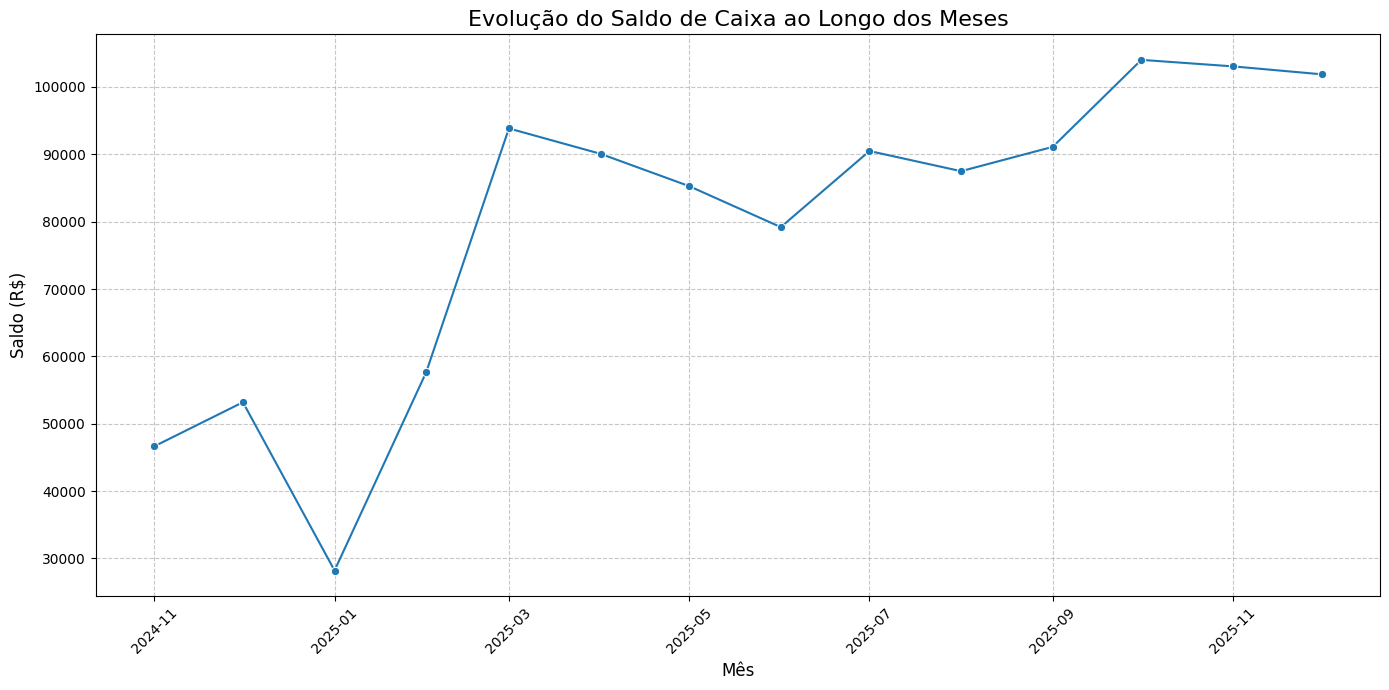

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assegurar que 'data' e 'mes' sejam datetime para ordenação correta
df_fluxo_caixa['data'] = pd.to_datetime(df_fluxo_caixa['data'], format='%d/%m/%y')
df_fluxo_caixa['mes'] = pd.to_datetime(df_fluxo_caixa['mes'])

# Ordenar por mês e data para garantir que o último saldo seja o correto para o final do mês
df_fluxo_caixa_sorted = df_fluxo_caixa.sort_values(by=['mes', 'data'])

# Obter o último saldo de cada mês
saldo_mensal_final = df_fluxo_caixa_sorted.groupby('mes')['saldo'].last().reset_index()

# Plotar a evolução do saldo de caixa
plt.figure(figsize=(14, 7))
sns.lineplot(x='mes', y='saldo', data=saldo_mensal_final, marker='o')
plt.title('Evolução do Saldo de Caixa ao Longo dos Meses', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Saldo (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Identificar meses com saldos negativos ou riscos de liquidez

# Filtrar meses onde o saldo é negativo ou zero
meses_com_risco = saldo_mensal_final[saldo_mensal_final['saldo'] <= 0]

print('\nMeses com saldos negativos ou riscos de liquidez:')
if not meses_com_risco.empty:
    display(meses_com_risco)
else:
    print('Nenhum mês identificado com saldo negativo ou risco de liquidez.')


Meses com saldos negativos ou riscos de liquidez:
Nenhum mês identificado com saldo negativo ou risco de liquidez.


In [14]:
# Calcular a variação do saldo de um mês para o outro
saldo_mensal_final['variacao_saldo'] = saldo_mensal_final['saldo'].diff()

# Filtrar apenas as quedas de saldo (valores negativos)
quedas_saldo = saldo_mensal_final[saldo_mensal_final['variacao_saldo'] < 0]

# Ordenar as quedas do maior para o menor
maiores_quedas = quedas_saldo.sort_values(by='variacao_saldo', ascending=True)

print('\nMeses com as maiores quedas de saldo (para investigar possíveis causas):')
if not maiores_quedas.empty:
    display(maiores_quedas[['mes', 'variacao_saldo']])
else:
    print('Nenhum mês identificado com queda de saldo.')


Meses com as maiores quedas de saldo (para investigar possíveis causas):


,mes,variacao_saldo
2,2025-01-01,-24990.51
7,2025-06-01,-6085.75
6,2025-05-01,-4802.41
5,2025-04-01,-3767.29
9,2025-08-01,-2991.75
13,2025-12-01,-1177.31
12,2025-11-01,-966.50


### Análise do Saldo Bancário ao Longo do Mês


Análise do saldo por dia do mês (médio, mínimo e máximo):


,dia_do_mes,mean,min,max
0,1,90699.529750,79497.76,104574.44
1,2,89564.756667,46951.80,107669.05
2,3,89598.280800,53573.38,105754.65
3,4,87748.301094,28505.67,103323.68
4,5,84780.671132,28812.82,104321.01



O dia do mês com o saldo mínimo mais baixo é o dia 13, com um saldo de R$ 287.09.


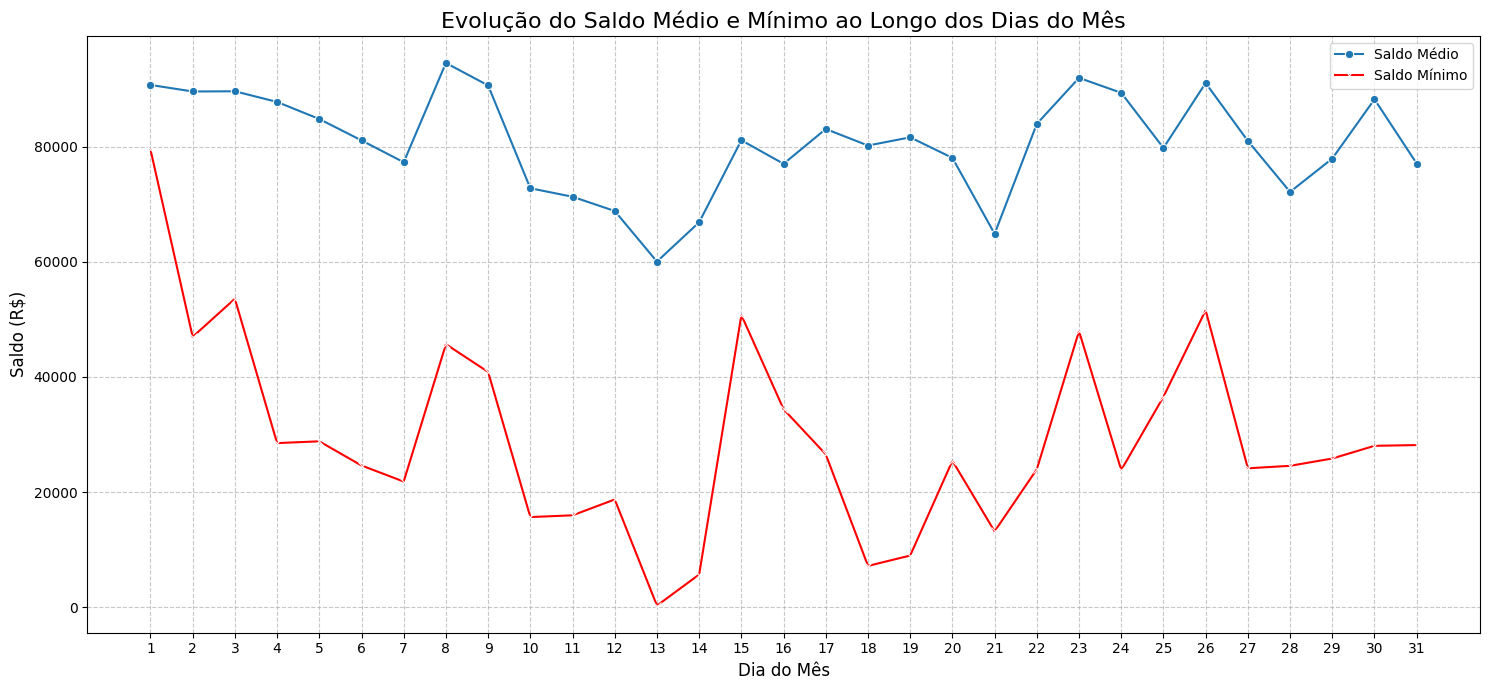

In [15]:
# 4) Analise o saldo bancário ao longo do mês no arquivo de fluxo de caixa. Em quais dias
# do mês o saldo atinge seu ponto mais baixo? Isso representa um risco operacional?

# Assegurar que a coluna 'data' seja do tipo datetime
df_fluxo_caixa['data'] = pd.to_datetime(df_fluxo_caixa['data'])

# Extrair o dia do mês
df_fluxo_caixa['dia_do_mes'] = df_fluxo_caixa['data'].dt.day

# Agrupar pelo dia do mês e calcular o saldo médio, mínimo e máximo para cada dia
análise_saldo_por_dia = df_fluxo_caixa.groupby('dia_do_mes')['saldo'].agg(['mean', 'min', 'max']).reset_index()

print('\nAnálise do saldo por dia do mês (médio, mínimo e máximo):')
display(análise_saldo_por_dia.head())

# Identificar o dia com o saldo mínimo mais baixo
dia_min_saldo_global = análise_saldo_por_dia.loc[análise_saldo_por_dia['min'].idxmin()]
print(f"\nO dia do mês com o saldo mínimo mais baixo é o dia {int(dia_min_saldo_global['dia_do_mes'])}, com um saldo de R$ {dia_min_saldo_global['min']:,.2f}.")

# Plotar a evolução do saldo médio e mínimo ao longo dos dias do mês
plt.figure(figsize=(15, 7))
sns.lineplot(x='dia_do_mes', y='mean', data=análise_saldo_por_dia, marker='o', label='Saldo Médio')
sns.lineplot(x='dia_do_mes', y='min', data=análise_saldo_por_dia, marker='x', color='red', label='Saldo Mínimo')
plt.title('Evolução do Saldo Médio e Mínimo ao Longo dos Dias do Mês', fontsize=16)
plt.xlabel('Dia do Mês', fontsize=12)
plt.ylabel('Saldo (R$)', fontsize=12)
plt.xticks(range(1, 32)) # Dias do mês
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# 5) Qual a média de 'Receita de Acordos e Multas' (1.1.14 e 1.1.20) comparada à 'Taxa Ordinária' (1.1.1)?
# O condomínio depende de inadimplentes pagando atrasado para fechar as contas?

# Filtrar receitas de acordos e multas (considerando os códigos 1.1.14 e 1.1.20 na descrição)
receita_acordos_multas = df_fluxo_caixa[df_fluxo_caixa['descricao'].str.contains('1.1.14|1.1.20', na=False, regex=True) & (df_fluxo_caixa['valor'] > 0)]
total_acordos_multas = receita_acordos_multas['valor'].sum()

# Filtrar 'Taxa Ordinária' (considerando o código 1.1.1 na descrição)
receita_taxa_ordinaria = df_fluxo_caixa[df_fluxo_caixa['descricao'].str.contains('1.1.1', na=False, regex=True) & (df_fluxo_caixa['valor'] > 0)]
total_taxa_ordinaria = receita_taxa_ordinaria['valor'].sum()

print(f"Total de Receita de Acordos e Multas: R$ {total_acordos_multas:,.2f}")
print(f"Total de Receita de Taxa Ordinária: R$ {total_taxa_ordinaria:,.2f}")

if total_taxa_ordinaria > 0:
    percentual_acordos_multas = (total_acordos_multas / total_taxa_ordinaria) * 100
    print(f"A Receita de Acordos e Multas representa {percentual_acordos_multas:,.2f}% da Receita de Taxa Ordinária.")

    if percentual_acordos_multas > 10: # Um valor de referência, pode ser ajustado conforme a análise de risco
        print("\nObservação: O percentual de Receita de Acordos e Multas é significativo em relação à Taxa Ordinária. Isso pode indicar uma dependência considerável de pagamentos de inadimplentes, o que representa um risco para o fluxo de caixa regular do condomínio.")
    else:
        print("\nObservação: O percentual de Receita de Acordos e Multas não parece ser um fator de grande dependência para o fechamento das contas, o que é um bom sinal de saúde financeira regular.")
else:
    print("Não foi possível calcular o percentual, pois o total da Taxa Ordinária é zero.")

Total de Receita de Acordos e Multas: R$ 0.00
Total de Receita de Taxa Ordinária: R$ 0.00
Não foi possível calcular o percentual, pois o total da Taxa Ordinária é zero.


### Perguntas de "Nível 3": Estratégia e "O Olhar do Sócio"

In [17]:
# 6) Se precisássemos reduzir os custos totais em 10% sem demitir funcionários da portaria, onde os dados sugerem que deveríamos focar?

# Filtrar rubricas de despesa que não são 'Portaria' ou 'Portaria Vigilância'
# As chaves 'Portaria Vigilância e Controle Acesso' e '2.4.1 Portaria Vigilância' parecem ser as mais relevantes para portaria.
# Vamos considerar quaisquer descrições que contenham 'Portaria' ou 'Vigilância' como relacionadas à portaria para exclusão.

rubricas_sem_portaria = total_despesas_por_rubrica[~total_despesas_por_rubrica.index.str.contains('Portaria|Vigilância', case=False, na=False)]

print('\nAs 5 maiores rubricas de despesa (excluindo portaria/vigilância) para focar na redução de 10% são:')
display(rubricas_sem_portaria.head(5))


As 5 maiores rubricas de despesa (excluindo portaria/vigilância) para focar na redução de 10% são:


,valor
descricao,
1.1.1 Taxa de Condominio,1109582.95
1.1.5 Taxa de Água,199092.27
2.5.1 INSS Retido de prestadores de serviços FORNECEDOR / PRESTADOR DE SERVIÇOS,102799.88
1.1.14 Homologação Acordo Extrajudicial,95975.50
2.4.5 Auxiliar de Manutenção Limpeza e jardinagem ref. 10/2025,74287.52


In [18]:
# 7) Com base no histórico de 2025, projete qual deve ser o saldo de caixa ao final do primeiro trimestre de 2026 se nenhuma taxa for reajustada.

# Filtrar dados para o ano de 2025
df_despesas_2025 = df_despesas[df_despesas['mes'].dt.year == 2025]
df_fluxo_caixa_2025 = df_fluxo_caixa[df_fluxo_caixa['mes'].dt.year == 2025]

# Calcular despesas mensais para 2025
despesas_mensais_2025 = df_despesas_2025.groupby('mes')['valor'].sum()

# Reutilizar faturamento_mensal, mas filtrar para 2025
faturamento_mensal_2025 = faturamento_mensal[faturamento_mensal.index.year == 2025]

# Calcular o fluxo de caixa líquido mensal para 2025
# É importante alinhar os índices (meses) para garantir que as operações sejam feitas corretamente
fluxo_caixa_liquido_mensal_2025 = faturamento_mensal_2025.reindex(despesas_mensais_2025.index, fill_value=0) - despesas_mensais_2025.reindex(faturamento_mensal_2025.index, fill_value=0)

# Calcular o fluxo de caixa líquido mensal médio de 2025
media_fluxo_caixa_liquido_mensal_2025 = fluxo_caixa_liquido_mensal_2025.mean()

print(f"Fluxo de caixa líquido mensal médio de 2025: R$ {media_fluxo_caixa_liquido_mensal_2025:,.2f}")

# Obter o saldo final de dezembro de 2025
saldo_dezembro_2025 = saldo_mensal_final[saldo_mensal_final['mes'].dt.strftime('%Y-%m') == '2025-12']['saldo'].iloc[0]

print(f"Saldo final de dezembro de 2025: R$ {saldo_dezembro_2025:,.2f}")

# Projeção para o primeiro trimestre de 2026
saldo_projetado_q1_2026 = saldo_dezembro_2025 + (media_fluxo_caixa_liquido_mensal_2025 * 3)

print(f"\nO saldo de caixa projetado para o final do primeiro trimestre de 2026, sem reajustes, é de R$ {saldo_projetado_q1_2026:,.2f}.")

Fluxo de caixa líquido mensal médio de 2025: R$ -142,087.39
Saldo final de dezembro de 2025: R$ 101,884.93

O saldo de caixa projetado para o final do primeiro trimestre de 2026, sem reajustes, é de R$ -324,377.25.


### Visualização da Tendência Mensal do Fluxo de Caixa Líquido em 2025

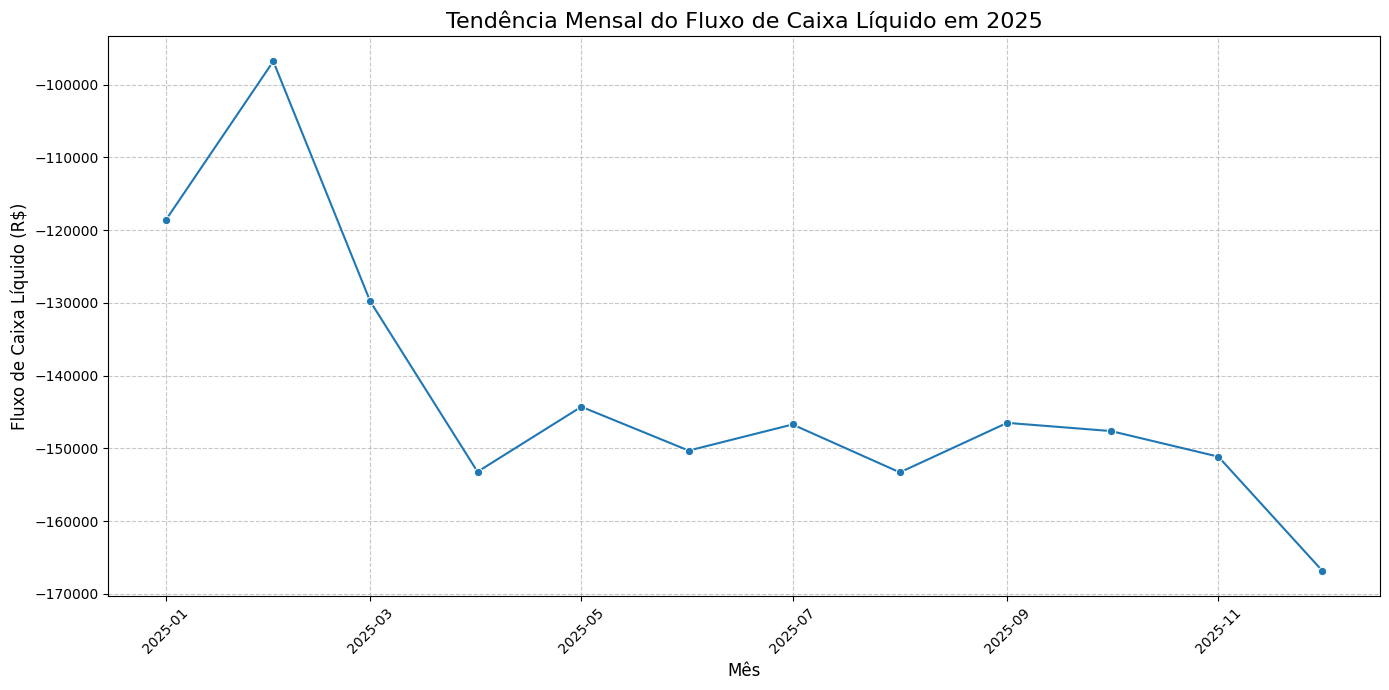


Meses com fluxo de caixa líquido negativo em 2025:


,mes,valor
0,2025-01-01,-118591.09
1,2025-02-01,-96802.78
2,2025-03-01,-129795.02
3,2025-04-01,-153213.16
4,2025-05-01,-144279.92
5,2025-06-01,-150304.04
6,2025-07-01,-146714.85
7,2025-08-01,-153298.68
8,2025-09-01,-146492.95
9,2025-10-01,-147620.19


In [19]:
# Visualizar a tendência mensal do fluxo de caixa líquido de 2025
plt.figure(figsize=(14, 7))
sns.lineplot(x=fluxo_caixa_liquido_mensal_2025.index, y=fluxo_caixa_liquido_mensal_2025.values, marker='o')
plt.title('Tendência Mensal do Fluxo de Caixa Líquido em 2025', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Fluxo de Caixa Líquido (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identificar meses com fluxo de caixa líquido negativo
meses_com_fluxo_negativo = fluxo_caixa_liquido_mensal_2025[fluxo_caixa_liquido_mensal_2025 < 0]

print('\nMeses com fluxo de caixa líquido negativo em 2025:')
if not meses_com_fluxo_negativo.empty:
    display(meses_com_fluxo_negativo.reset_index())
else:
    print('Nenhum mês em 2025 apresentou fluxo de caixa líquido negativo.')

### Análise das Rubricas de Despesa com Maior Potencial de Redução

In [20]:
# Reexibindo as rubricas de despesa com maior potencial de redução (excluindo portaria/vigilância)
print('As rubricas de despesa com maior potencial de redução (excluindo portaria/vigilância) são:')
display(rubricas_sem_portaria.head(5))

As rubricas de despesa com maior potencial de redução (excluindo portaria/vigilância) são:


,valor
descricao,
1.1.1 Taxa de Condominio,1109582.95
1.1.5 Taxa de Água,199092.27
2.5.1 INSS Retido de prestadores de serviços FORNECEDOR / PRESTADOR DE SERVIÇOS,102799.88
1.1.14 Homologação Acordo Extrajudicial,95975.50
2.4.5 Auxiliar de Manutenção Limpeza e jardinagem ref. 10/2025,74287.52


In [21]:
# 8) Considere o gasto com 'Honorários Jurídicos'. Esse valor é condizente com o volume de acordos recuperados ou o jurídico é apenas um centro de custo passivo?

# Filtrar despesas com 'Honorários Jurídicos'
despesas_juridicas = df_despesas[df_despesas['descricao'].str.contains('Honorários Jurídicos|Jurídica', case=False, na=False)]
total_despesas_juridicas = despesas_juridicas['valor'].sum()

# Filtrar receitas de acordos recuperados (já calculados anteriormente como 'receita_acordos_multas')
total_acordos_recuperados = receita_acordos_multas['valor'].sum() # Reutilizando a variável de acordos e multas

print(f"\nTotal de Despesas com Honorários Jurídicos: R$ {total_despesas_juridicas:,.2f}")
print(f"Total de Receitas de Acordos Recuperados: R$ {total_acordos_recuperados:,.2f}")

if total_despesas_juridicas > 0:
    # Para analisar o ROI, podemos comparar a receita recuperada com o custo jurídico.
    # Um ROI > 1 (ou percentual > 100%) indicaria que o jurídico gerou mais receita do que custou.
    roi_juridico = (total_acordos_recuperados / total_despesas_juridicas) * 100
    print(f"O ROI dos serviços jurídicos (receita de acordos recuperados sobre despesa jurídica) é de {roi_juridico:,.2f}%.")

    if roi_juridico >= 100:
        print("Observação: O valor gasto com 'Honorários Jurídicos' parece condizente, gerando mais receita em acordos recuperados do que o custo.")
    elif roi_juridico > 0:
        print("Observação: Os serviços jurídicos contribuem para a recuperação de acordos, mas o custo ainda é superior à receita recuperada. Pode ser necessário avaliar a eficiência ou a estratégia.")
    else:
        print("Observação: Não houve receita de acordos recuperados ou ela foi insignificante em relação ao custo jurídico. Isso pode indicar que o jurídico está agindo mais como um centro de custo passivo, sem retorno direto aparente através de acordos recuperados.")
else:
    print("Não foi possível calcular o ROI, pois não há despesas com Honorários Jurídicos registradas para o período.")


Total de Despesas com Honorários Jurídicos: R$ 164,061.15
Total de Receitas de Acordos Recuperados: R$ 0.00
O ROI dos serviços jurídicos (receita de acordos recuperados sobre despesa jurídica) é de 0.00%.
Observação: Não houve receita de acordos recuperados ou ela foi insignificante em relação ao custo jurídico. Isso pode indicar que o jurídico está agindo mais como um centro de custo passivo, sem retorno direto aparente através de acordos recuperados.
